In [5]:
## automatically reload 
%reload_ext autoreload
%autoreload 2

In [11]:
import sys
sys.path.insert(0, "../../src")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import neoscore as nsc

#new s3m loader
import s3m_loader as load_s3m

import importlib
from functools import reduce
importlib.reload(nm3)
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import get_sun, SkyCoord, GCRS

from tqdm import tqdm

In [9]:
s3m = load_s3m.define_s3m("mba", verbose=True)  # defaults to pop="mba"

Search pattern: S1_*.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./S1_00.s3m', './S1_01.s3m', './S1_02.s3m', './S1_03.s3m', './S1_04.s3m', './S1_05.s3m', './S1_06.s3m', './S1_07.s3m', './S1_08.s3m', './S1_09.s3m', './S1_10.s3m', './S1_11.s3m', './S1_12.s3m', './S1_13.s3m']
Loaded 14 file(s).
Final dataframe shape: (13883361, 15)
The final df is done.


In [10]:
s3m, array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m = load_s3m.s3m_array(s3m)
scorer_mba_s3m = nsc.NEOMODScorer(array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m)

In [12]:
obstime_str = "2025-03-21T00:00:00"
t_obs = Time(obstime_str, scale="tdb")

max_sep_deg = 30.0         
Nsample = None              

xlim = (-0.8, 0.8)
ylim = (-0.8, 0.8)
bins = 100                  

AU_km  = 149_597_870.7
mu_sun = 1.32712440018e11   # km^3/s^2


In [13]:
#Pull columns

a_AU   = s3m["a"].to_numpy(dtype=float)
e      = s3m["e"].to_numpy(dtype=float)
inc    = s3m["i"].to_numpy(dtype=float)        # deg
raan   = s3m["node"].to_numpy(dtype=float)     # deg
argp   = s3m["argperi"].to_numpy(dtype=float)  # deg
tp_mjd = s3m["t_p"].to_numpy(dtype=float)      # MJD

N = len(a_AU)
if (Nsample is not None) and (N > Nsample):
    idx = np.random.choice(N, Nsample, replace=False)
    a_AU, e, inc, raan, argp, tp_mjd = a_AU[idx], e[idx], inc[idx], raan[idx], argp[idx], tp_mjd[idx]
    print("Sample size:", len(a_AU))
else:
    print("Using ALL rows:", len(a_AU))

r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
    a_AU=a_AU,
    e=e,
    inc_deg=inc,
    raan_deg=raan,
    argp_deg=argp,
    tp_mjd=tp_mjd,
    obstime_str=obstime_str,
    method="newton",      # change to "adam" to use ADAM
    n_iter=10,
    chunk=300_000,
    show_progress=True,
)
#Ecliptic -> Equatorial 
eps = np.deg2rad(23.439291)
c, s = np.cos(eps), np.sin(eps)

r_obj_helio = np.column_stack([
    r_obj_ecl[:, 0],
    c*r_obj_ecl[:, 1] - s*r_obj_ecl[:, 2],
    s*r_obj_ecl[:, 1] + c*r_obj_ecl[:, 2],
])

v_obj_helio = np.column_stack([
    v_obj_ecl[:, 0],
    c*v_obj_ecl[:, 1] - s*v_obj_ecl[:, 2],
    s*v_obj_ecl[:, 1] + c*v_obj_ecl[:, 2],
])

# Observer state from scorer (Earth + Rubin topocenter)

_, rE, vE, r_tele = scorer_mba_s3m._get_earth_and_observer(obstime_str)

# Topocentric relative vectors (aka r_rel, v_rel)
r_rel = r_obj_helio - (rE + r_tele)   # km
v_rel = v_obj_helio - vE              # km/s

#(r_rel, v_rel) -> RA/Dec and RA/Dec rates
x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

rho2 = x*x + y*y
r2   = rho2 + z*z
rho  = np.sqrt(rho2)

ra  = np.arctan2(y, x)
dec = np.arctan2(z, rho)

dra  = (x*vy - y*vx) / rho2
ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)


good = (
    np.isfinite(ra) & np.isfinite(dec) &
    np.isfinite(dra) & np.isfinite(ddec) &
    (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
)

ra_deg  = (np.rad2deg(ra[good]) % 360.0)
dec_deg = np.rad2deg(dec[good])

# dra/ddec above are rad/s -> convert to deg/day
dra_deg_day  = np.rad2deg(dra[good])  * 86400.0
ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

#Anti-sun cone cut
sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
anti = SkyCoord(
    x=-sun_gcrs.cartesian.x,
    y=-sun_gcrs.cartesian.y,
    z=-sun_gcrs.cartesian.z,
    representation_type="cartesian",
    frame=GCRS(obstime=t_obs),
)

anti_ra_deg  = anti.spherical.lon.to_value(u.deg) % 360.0
anti_dec_deg = anti.spherical.lat.to_value(u.deg)

print("anti-sun RA,Dec:", anti_ra_deg, anti_dec_deg)

sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))
anti_sc = SkyCoord(ra=anti_ra_deg*u.deg, dec=anti_dec_deg*u.deg, frame=GCRS(obstime=t_obs))
sep = sc.separation(anti_sc).deg

m = sep <= max_sep_deg
ra_deg, dec_deg = ra_deg[m], dec_deg[m]
dra_deg_day, ddec_deg_day = dra_deg_day[m], ddec_deg_day[m]

print(f"After anti-sun sep < {max_sep_deg}°:", len(ra_deg))
# RA/Dec rates -> ecliptic rates

vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
    ra_deg, dec_deg,
    dra_deg_day, ddec_deg_day,
    obstime_str
)

finite = np.isfinite(vlam) & np.isfinite(vbeta)
vlam = vlam[finite]
vbeta = vbeta[finite]

# copying vlam/vbet values

vlam_mba  = vlam.copy()
vbeta_mba = vbeta.copy()

Using ALL rows: 13883361


Propagate with newton: 100%|██████████| 47/47 [00:11<00:00,  4.15it/s]


anti-sun RA,Dec: 180.2447707411587 -0.10555404868149516
After anti-sun sep < 30.0°: 1409982


#### NEO's

In [14]:
neo = load_s3m.define_s3m(pop="neo")
neo, array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo = load_s3m.s3m_array(neo)
scorer_neo_s3m = nsc.NEOMODScorer(array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo)

Search pattern: S0.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./S0.s3m']
Loaded 1 file(s).
Final dataframe shape: (268511, 15)
The final df is done.


In [15]:
#Pull columns

a_AU   = neo["a"].to_numpy(dtype=float)
e      = neo["e"].to_numpy(dtype=float)
inc    = neo["i"].to_numpy(dtype=float)        # deg
raan   = neo["node"].to_numpy(dtype=float)     # deg
argp   = neo["argperi"].to_numpy(dtype=float)  # deg
tp_mjd = neo["t_p"].to_numpy(dtype=float)      # MJD

N = len(a_AU)
if (Nsample is not None) and (N > Nsample):
    idx = np.random.choice(N, Nsample, replace=False)
    a_AU, e, inc, raan, argp, tp_mjd = a_AU[idx], e[idx], inc[idx], raan[idx], argp[idx], tp_mjd[idx]
    print("Sample size:", len(a_AU))
else:
    print("Using ALL rows:", len(a_AU))


r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
    a_AU=a_AU,
    e=e,
    inc_deg=inc,
    raan_deg=raan,
    argp_deg=argp,
    tp_mjd=tp_mjd,
    obstime_str=obstime_str,
    method="newton",      # change to "adam" to use ADAM
    n_iter=10,
    chunk=300_000,
    show_progress=True,
)


#Ecliptic -> Equatorial 

eps = np.deg2rad(23.439291)
c, s = np.cos(eps), np.sin(eps)

r_obj_helio = np.column_stack([
    r_obj_ecl[:, 0],
    c*r_obj_ecl[:, 1] - s*r_obj_ecl[:, 2],
    s*r_obj_ecl[:, 1] + c*r_obj_ecl[:, 2],
])

v_obj_helio = np.column_stack([
    v_obj_ecl[:, 0],
    c*v_obj_ecl[:, 1] - s*v_obj_ecl[:, 2],
    s*v_obj_ecl[:, 1] + c*v_obj_ecl[:, 2],
])


# Observer state from scorer (Earth + Rubin topocenter)

_, rE, vE, r_tele = scorer_neo_s3m._get_earth_and_observer(obstime_str)

# Topocentric relative vectors (aka r_rel, v_rel)
r_rel = r_obj_helio - (rE + r_tele)   # km
v_rel = v_obj_helio - vE              # km/s


#(r_rel, v_rel) -> RA/Dec and RA/Dec rates

x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

rho2 = x*x + y*y
r2   = rho2 + z*z
rho  = np.sqrt(rho2)

ra  = np.arctan2(y, x)
dec = np.arctan2(z, rho)

dra  = (x*vy - y*vx) / rho2
ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

good = (
    np.isfinite(ra) & np.isfinite(dec) &
    np.isfinite(dra) & np.isfinite(ddec) &
    (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
)

ra_deg  = (np.rad2deg(ra[good]) % 360.0)
dec_deg = np.rad2deg(dec[good])

# dra/ddec above are rad/s -> convert to deg/day
dra_deg_day  = np.rad2deg(dra[good])  * 86400.0
ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

print("After good-mask:", len(ra_deg))


#Anti-sun cone cut

sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
anti = SkyCoord(
    x=-sun_gcrs.cartesian.x,
    y=-sun_gcrs.cartesian.y,
    z=-sun_gcrs.cartesian.z,
    representation_type="cartesian",
    frame=GCRS(obstime=t_obs),
)

anti_ra_deg  = anti.spherical.lon.to_value(u.deg) % 360.0
anti_dec_deg = anti.spherical.lat.to_value(u.deg)

sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))
anti_sc = SkyCoord(ra=anti_ra_deg*u.deg, dec=anti_dec_deg*u.deg, frame=GCRS(obstime=t_obs))
sep = sc.separation(anti_sc).deg

m = sep <= max_sep_deg
ra_deg, dec_deg = ra_deg[m], dec_deg[m]
dra_deg_day, ddec_deg_day = dra_deg_day[m], ddec_deg_day[m]

print(f"After anti-sun sep < {max_sep_deg}°:", len(ra_deg))


# RA/Dec rates -> ecliptic rates

vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
    ra_deg, dec_deg,
    dra_deg_day, ddec_deg_day,
    obstime_str
)

finite = np.isfinite(vlam) & np.isfinite(vbeta)
vlam = vlam[finite]
vbeta = vbeta[finite]
print("Finite vlam/vbeta:", len(vlam))

# copying vlam/vbet values
vlam_neo  = vlam.copy()
vbeta_neo = vbeta.copy()

Using ALL rows: 268511


Propagate with newton: 100%|██████████| 1/1 [00:00<00:00,  4.95it/s]

After good-mask: 268511
After anti-sun sep < 30.0°: 13485
Finite vlam/vbeta: 13485


#### TNO's

In [16]:
tno = load_s3m.define_s3m(pop="tno")
tno, array4D_tno, H_center_tno, a_center_tno, e_center_tno, i_center_tno = load_s3m.s3m_array(tno)
scorer_tno_s3m = nsc.NEOMODScorer(array4D_tno, H_center_tno, a_center_tno, e_center_tno, i_center_tno)

Search pattern: ST.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./ST.s3m']
Loaded 1 file(s).
Final dataframe shape: (48682, 15)
The final df is done.


In [23]:
#Pull columns

a_AU   = tno["a"].to_numpy(dtype=float)
e      = tno["e"].to_numpy(dtype=float)
inc    = tno["i"].to_numpy(dtype=float)        # deg
raan   = tno["node"].to_numpy(dtype=float)     # deg
argp   = tno["argperi"].to_numpy(dtype=float)  # deg
tp_mjd = tno["t_p"].to_numpy(dtype=float)      # MJD

N = len(a_AU)
if (Nsample is not None) and (N > Nsample):
    idx = np.random.choice(N, Nsample, replace=False)
    a_AU, e, inc, raan, argp, tp_mjd = a_AU[idx], e[idx], inc[idx], raan[idx], argp[idx], tp_mjd[idx]
    print("Sample size:", len(a_AU))
else:
    print("Using ALL rows:", len(a_AU))


r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
    a_AU=a_AU,
    e=e,
    inc_deg=inc,
    raan_deg=raan,
    argp_deg=argp,
    tp_mjd=tp_mjd,
    obstime_str=obstime_str,
    method="newton",      # change to "adam" to use ADAM
    n_iter=10,
    chunk=300_000,
    show_progress=True,
)

#Ecliptic -> Equatorial 

eps = np.deg2rad(23.439291)
c, s = np.cos(eps), np.sin(eps)

r_obj_helio = np.column_stack([
    r_obj_ecl[:, 0],
    c*r_obj_ecl[:, 1] - s*r_obj_ecl[:, 2],
    s*r_obj_ecl[:, 1] + c*r_obj_ecl[:, 2],
])

v_obj_helio = np.column_stack([
    v_obj_ecl[:, 0],
    c*v_obj_ecl[:, 1] - s*v_obj_ecl[:, 2],
    s*v_obj_ecl[:, 1] + c*v_obj_ecl[:, 2],
])


# Observer state from scorer (Earth + Rubin topocenter)

_, rE, vE, r_tele = scorer_tno_s3m._get_earth_and_observer(obstime_str)

# Topocentric relative vectors (aka r_rel, v_rel)
r_rel = r_obj_helio - (rE + r_tele)   # km
v_rel = v_obj_helio - vE              # km/s


#(r_rel, v_rel) -> RA/Dec and RA/Dec rates

x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

rho2 = x*x + y*y
r2   = rho2 + z*z
rho  = np.sqrt(rho2)

ra  = np.arctan2(y, x)
dec = np.arctan2(z, rho)

dra  = (x*vy - y*vx) / rho2
ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

good = (
    np.isfinite(ra) & np.isfinite(dec) &
    np.isfinite(dra) & np.isfinite(ddec) &
    (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
)

ra_deg  = (np.rad2deg(ra[good]) % 360.0)
dec_deg = np.rad2deg(dec[good])

# dra/ddec above are rad/s -> convert to deg/day
dra_deg_day  = np.rad2deg(dra[good])  * 86400.0
ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

print("After good-mask:", len(ra_deg))


#Anti-sun cone cut

sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
anti = SkyCoord(
    x=-sun_gcrs.cartesian.x,
    y=-sun_gcrs.cartesian.y,
    z=-sun_gcrs.cartesian.z,
    representation_type="cartesian",
    frame=GCRS(obstime=t_obs),
)

anti_ra_deg  = anti.spherical.lon.to_value(u.deg) % 360.0
anti_dec_deg = anti.spherical.lat.to_value(u.deg)

sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))
anti_sc = SkyCoord(ra=anti_ra_deg*u.deg, dec=anti_dec_deg*u.deg, frame=GCRS(obstime=t_obs))
sep = sc.separation(anti_sc).deg

m = sep <= max_sep_deg
ra_deg, dec_deg = ra_deg[m], dec_deg[m]
dra_deg_day, ddec_deg_day = dra_deg_day[m], ddec_deg_day[m]

print(f"After anti-sun sep < {max_sep_deg}°:", len(ra_deg))


# RA/Dec rates -> ecliptic rates

vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
    ra_deg, dec_deg,
    dra_deg_day, ddec_deg_day,
    obstime_str
)

finite = np.isfinite(vlam) & np.isfinite(vbeta)
vlam = vlam[finite]
vbeta = vbeta[finite]
print("Finite vlam/vbeta:", len(vlam))

# copying vlam/vbet values
vlam_tno  = vlam.copy()
vbeta_tno = vbeta.copy()

Using ALL rows: 48682


Propagate with newton: 100%|██████████| 1/1 [00:00<00:00, 26.05it/s]

After good-mask: 48682
After anti-sun sep < 30.0°: 7417
Finite vlam/vbeta: 7417


#### Jupiter Trojans

In [24]:
trojan = load_s3m.define_s3m(pop="trojan")
trojan,array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn = load_s3m.s3m_array(trojan)
scorer_tjn_s3m = nsc.NEOMODScorer(array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn)

Search pattern: St5.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./St5.s3m']
Loaded 1 file(s).
Final dataframe shape: (179882, 15)
The final df is done.


In [25]:
#Pull columns

a_AU   = trojan["a"].to_numpy(dtype=float)
e      = trojan["e"].to_numpy(dtype=float)
inc    = trojan["i"].to_numpy(dtype=float)        # deg
raan   = trojan["node"].to_numpy(dtype=float)     # deg
argp   = trojan["argperi"].to_numpy(dtype=float)  # deg
tp_mjd = trojan["t_p"].to_numpy(dtype=float)      # MJD

N = len(a_AU)
if (Nsample is not None) and (N > Nsample):
    idx = np.random.choice(N, Nsample, replace=False)
    a_AU, e, inc, raan, argp, tp_mjd = a_AU[idx], e[idx], inc[idx], raan[idx], argp[idx], tp_mjd[idx]
    print("Sample size:", len(a_AU))
else:
    print("Using ALL rows:", len(a_AU))


r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
    a_AU=a_AU,
    e=e,
    inc_deg=inc,
    raan_deg=raan,
    argp_deg=argp,
    tp_mjd=tp_mjd,
    obstime_str=obstime_str,
    method="newton",      # change to "adam" to use ADAM
    n_iter=10,
    chunk=300_000,
    show_progress=True,
)


#Ecliptic -> Equatorial 

eps = np.deg2rad(23.439291)
c, s = np.cos(eps), np.sin(eps)

r_obj_helio = np.column_stack([
    r_obj_ecl[:, 0],
    c*r_obj_ecl[:, 1] - s*r_obj_ecl[:, 2],
    s*r_obj_ecl[:, 1] + c*r_obj_ecl[:, 2],
])

v_obj_helio = np.column_stack([
    v_obj_ecl[:, 0],
    c*v_obj_ecl[:, 1] - s*v_obj_ecl[:, 2],
    s*v_obj_ecl[:, 1] + c*v_obj_ecl[:, 2],
])


# Observer state from scorer (Earth + Rubin topocenter)

_, rE, vE, r_tele = scorer_tjn_s3m._get_earth_and_observer(obstime_str)

# Topocentric relative vectors (aka r_rel, v_rel)
r_rel = r_obj_helio - (rE + r_tele)   # km
v_rel = v_obj_helio - vE              # km/s


#(r_rel, v_rel) -> RA/Dec and RA/Dec rates

x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

rho2 = x*x + y*y
r2   = rho2 + z*z
rho  = np.sqrt(rho2)

ra  = np.arctan2(y, x)
dec = np.arctan2(z, rho)

dra  = (x*vy - y*vx) / rho2
ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

good = (
    np.isfinite(ra) & np.isfinite(dec) &
    np.isfinite(dra) & np.isfinite(ddec) &
    (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
)

ra_deg  = (np.rad2deg(ra[good]) % 360.0)
dec_deg = np.rad2deg(dec[good])

# dra/ddec above are rad/s -> convert to deg/day
dra_deg_day  = np.rad2deg(dra[good])  * 86400.0
ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

print("After good-mask:", len(ra_deg))


#Anti-sun cone cut

sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
anti = SkyCoord(
    x=-sun_gcrs.cartesian.x,
    y=-sun_gcrs.cartesian.y,
    z=-sun_gcrs.cartesian.z,
    representation_type="cartesian",
    frame=GCRS(obstime=t_obs),
)

anti_ra_deg  = anti.spherical.lon.to_value(u.deg) % 360.0
anti_dec_deg = anti.spherical.lat.to_value(u.deg)

sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))
anti_sc = SkyCoord(ra=anti_ra_deg*u.deg, dec=anti_dec_deg*u.deg, frame=GCRS(obstime=t_obs))
sep = sc.separation(anti_sc).deg

m = sep <= max_sep_deg
ra_deg, dec_deg = ra_deg[m], dec_deg[m]
dra_deg_day, ddec_deg_day = dra_deg_day[m], ddec_deg_day[m]

print(f"After anti-sun sep < {max_sep_deg}°:", len(ra_deg))


# RA/Dec rates -> ecliptic rates

vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
    ra_deg, dec_deg,
    dra_deg_day, ddec_deg_day,
    obstime_str
)

finite = np.isfinite(vlam) & np.isfinite(vbeta)
vlam = vlam[finite]
vbeta = vbeta[finite]
print("Finite vlam/vbeta:", len(vlam))

# copying vlam/vbet values
vlam_tjn  = vlam.copy()
vbeta_tjn = vbeta.copy()

Using ALL rows: 179882


Propagate with newton: 100%|██████████| 1/1 [00:00<00:00,  7.45it/s]

After good-mask: 179882


After anti-sun sep < 30.0°: 23188
Finite vlam/vbeta: 23188


In [28]:
from scipy.spatial import cKDTree

# Grid / plotting window in ecliptic-rate space
xlim = (-0.8, 0.8)   # v_lambda range [deg/day]
ylim = (-0.8, 0.8)   # v_beta   range [deg/day]

# Uniform grid spacing
# 0.01 as grid step
grid_step = 0.01

# Grid coordinates
x_grid = np.arange(xlim[0], xlim[1] + grid_step, grid_step)
y_grid = np.arange(ylim[0], ylim[1] + grid_step, grid_step)

# 2D mesh of evaluation points
X0, Y0 = np.meshgrid(x_grid, y_grid, indexing="xy")

# Flattened list of evaluation points: shape (Ngrid, 2)
grid_points = np.column_stack([X0.ravel(), Y0.ravel()])

print("Grid shape:", X0.shape)
print("Number of evaluation points:", len(grid_points))

Grid shape: (161, 161)
Number of evaluation points: 25921


In [29]:
# Build (x, y) arrays for each population

pts_mba = np.column_stack([vlam_mba, vbeta_mba])
pts_neo = np.column_stack([vlam_neo, vbeta_neo])
pts_tno = np.column_stack([vlam_tno, vbeta_tno])
pts_tjn = np.column_stack([vlam_tjn, vbeta_tjn])

# Combined population
pts_all = np.vstack([pts_mba, pts_neo, pts_tno, pts_tjn])

print("MBA points :", pts_mba.shape)
print("NEO points :", pts_neo.shape)
print("TNO points :", pts_tno.shape)
print("TJN points :", pts_tjn.shape)
print("ALL points :", pts_all.shape)


# Build KD-trees to compute distances 

tree_mba = cKDTree(pts_mba)
tree_neo = cKDTree(pts_neo)
tree_tno = cKDTree(pts_tno)
tree_tjn = cKDTree(pts_tjn)
tree_all = cKDTree(pts_all)

print("KD-trees built successfully.")

MBA points : (1409982, 2)
NEO points : (13485, 2)
TNO points : (7417, 2)
TJN points : (23188, 2)
ALL points : (1454072, 2)
KD-trees built successfully.


In [30]:
#Get nearest-neighbor distances for any tree

def get_knn_distances(tree, x0, y0, k=10):
    """
    Return distances from evaluation point (x0, y0)
    to its k nearest neighbors in the given KD-tree.

    Parameters
    ----------
    tree : scipy.spatial.cKDTree
        KD-tree built from a population's (v_lambda, v_beta) points.
    x0, y0 : float
        Evaluation point coordinates.
    k : int
        Number of nearest neighbors.

    Returns
    -------
    d : ndarray, shape (k,)
        Sorted nearest-neighbor distances.
    idx : ndarray, shape (k,)
        Indices of those neighbors in the original point array.
    """
    q = np.array([[x0, y0]])
    d, idx = tree.query(q, k=k)
    return d[0], idx[0]

In [31]:
from math import lgamma
# Based on Appendix B posterior in 2D for one evaluation point

def log_posterior_d0_2d(d0_grid, d_knn):
    """
    Compute the unnormalized log-posterior log p(d0 | d_1,...,d_N)
    for the 2D Appendix B nearest-neighbor Bayesian density estimator.

    Parameters
    ----------
    d0_grid : ndarray, shape (M,)
        Trial values of d0 (local spacing) at which to evaluate the posterior.
        Must be strictly positive.
    d_knn : ndarray, shape (N,)
        Sorted nearest-neighbor distances d_1,...,d_N.

    Returns
    -------
    logp : ndarray, shape (M,)
        Unnormalized log-posterior values on d0_grid.
    """
    # Small d0 = points close to each other, big d0 = points sparse
    d0_grid = np.asarray(d0_grid, dtype=float)
    d_knn = np.asarray(d_knn, dtype=float)

    if np.any(d0_grid <= 0):
        raise ValueError("All d0_grid values must be > 0.")
    if np.any(d_knn <= 0):
        raise ValueError("All nearest-neighbor distances must be > 0.")

    N = len(d_knn)
    k_vals = np.arange(1, N + 1)

    logp = np.zeros_like(d0_grid, dtype=float)

    for i, d0 in enumerate(d0_grid):
        term_sum = 0.0

        for k, dk in zip(k_vals, d_knn):
            # log of:
            # 2 / [ d0 (k-1)! ] * exp(-(dk/d0)^2) * (dk/d0)^(2k-1)
            term = (
                np.log(2.0)
                - np.log(d0)
                - lgamma(k)                      # log((k-1)!)
                - (dk / d0) ** 2
                + (2 * k - 1) * np.log(dk / d0)
            )
            term_sum += term

        logp[i] = term_sum

    return logp


# Normalize posterior sampled on a d0 grid

def normalize_posterior_from_loggrid(d0_grid, logp):
    """
    Normalize a posterior sampled on a d0 grid.

    Parameters
    ----------
    d0_grid : ndarray
        Grid of d0 values.
    logp : ndarray
        Unnormalized log-posterior evaluated on d0_grid.

    Returns
    -------
    p_norm : ndarray
        Normalized posterior p(d0 | data) on the grid,
        such that integral p_norm dd0 = 1.
    """
    d0_grid = np.asarray(d0_grid, dtype=float)
    logp = np.asarray(logp, dtype=float)

    # shift by max for numerical stability
    logp_shift = logp - np.max(logp)
    p_unnorm = np.exp(logp_shift)

    # normalize by trapezoid rule
    norm = np.trapz(p_unnorm, d0_grid)
    if norm <= 0 or not np.isfinite(norm):
        raise ValueError("Posterior normalization failed.")

    p_norm = p_unnorm / norm
    return p_norm


In [32]:
# Full-posterior density estimate at one evaluation point

def estimate_density_full_posterior_2d(
    tree,
    x0,
    y0,
    k=10,
    d0_min_factor=5.0,
    d0_max_factor=10.0,
    n_d0_grid=800,
    return_diagnostics=False,
):
    """
    Estimate local 2D density at one evaluation point (x0, y0)
    using the full Appendix B posterior.

    Parameters
    ----------
    tree : scipy.spatial.cKDTree
        KD-tree built from the population points in (v_lambda, v_beta).
    x0, y0 : float
        Evaluation point coordinates.
    k : int, default=10
        Number of nearest neighbors.
    d0_min_factor : float, default=5.0
        Lower d0 grid bound is d_1 / d0_min_factor.
    d0_max_factor : float, default=10.0
        Upper d0 grid bound is d_k * d0_max_factor.
    n_d0_grid : int, default=800
        Number of trial d0 points in the posterior grid.
    return_diagnostics : bool, default=False
        If True, also return diagnostic quantities.

    Returns
    -------
    n0_mean : float
        Posterior mean density <n0>.
    
    If return_diagnostics=True, also returns a dict with:
        d_knn, d0_grid, p_d0, d0_map, d0_mean, n0_map, n0_mean
    """
    # nearest-neighbor distances
    d_knn, idx_knn = get_knn_distances(tree, x0, y0, k=k)

    # build d0 grid
    d0_min = d_knn[0] / d0_min_factor
    d0_max = d_knn[-1] * d0_max_factor
    d0_grid = np.logspace(np.log10(d0_min), np.log10(d0_max), n_d0_grid)

    # posterior in d0
    logp_d0 = log_posterior_d0_2d(d0_grid, d_knn)
    p_d0 = normalize_posterior_from_loggrid(d0_grid, logp_d0)

    # convert to density n0 = 1 / (pi d0^2)
    n0_grid = 1.0 / (np.pi * d0_grid**2)

   
    d0_map = d0_grid[np.argmax(p_d0)]
    d0_mean = np.trapz(d0_grid * p_d0, d0_grid)
    n0_map = 1.0 / (np.pi * d0_map**2)
    n0_mean = np.trapz(n0_grid * p_d0, d0_grid)

    if return_diagnostics:
        diag = {
            "d_knn": d_knn,
            "d0_grid": d0_grid,
            "p_d0": p_d0,
            "d0_map": d0_map,
            "d0_mean": d0_mean,
            "n0_map": n0_map,
            "n0_mean": n0_mean,
        }
        return n0_mean, diag

    return n0_mean

In [33]:
# Evaluate full-posterior density on the whole grid

from tqdm import tqdm

def evaluate_density_map_full_posterior_2d(
    tree,
    grid_points,
    k=10,
    d0_min_factor=5.0,
    d0_max_factor=10.0,
    n_d0_grid=400,
    show_progress=True,
):
    """
    Evaluate posterior-mean density on a full set of evaluation points.

    Parameters
    ----------
    tree : scipy.spatial.cKDTree
        KD-tree built from the population points.
    grid_points : ndarray, shape (Ngrid, 2)
        Evaluation points [(x0,y0), ...].
    k : int, default=10
        Number of nearest neighbors.
    d0_min_factor, d0_max_factor : float
        Factors setting the d0 grid range for each evaluation point.
    n_d0_grid : int, default=400
        Number of d0 samples per evaluation point.
        Use 400 for a first full-map test; increase later if needed.
    show_progress : bool, default=True
        Show tqdm progress bar.

    Returns
    -------
    density_vals : ndarray, shape (Ngrid,)
        Posterior mean density at each evaluation point.
    """
    density_vals = np.empty(len(grid_points), dtype=float)

    iterator = enumerate(grid_points)
    if show_progress:
        iterator = tqdm(iterator, total=len(grid_points), desc="Evaluating density map")

    for i, (x0, y0) in iterator:
        density_vals[i] = estimate_density_full_posterior_2d(
            tree,
            x0,
            y0,
            k=k,
            d0_min_factor=d0_min_factor,
            d0_max_factor=d0_max_factor,
            n_d0_grid=n_d0_grid,
            return_diagnostics=False,
        )

    return density_vals

In [35]:
# First full-map run on ALL populations

k_map = 10
n_d0_grid_map = 400   # lighter than 800 for first full-map test

density_all_flat = evaluate_density_map_full_posterior_2d(
    tree_all,
    grid_points,
    k=k_map,
    n_d0_grid=n_d0_grid_map,
    show_progress=True,
)

print("Done.")
print("density_all_flat shape:", density_all_flat.shape)
print("min density:", np.nanmin(density_all_flat))
print("max density:", np.nanmax(density_all_flat))
print("median density:", np.nanmedian(density_all_flat))

Evaluating density map: 100%|██████████| 25921/25921 [08:06<00:00, 53.32it/s]

Done.
density_all_flat shape: (25921,)
min density: 5.552269206645225
max density: 1549739909.3767836
median density: 182.45902884447358


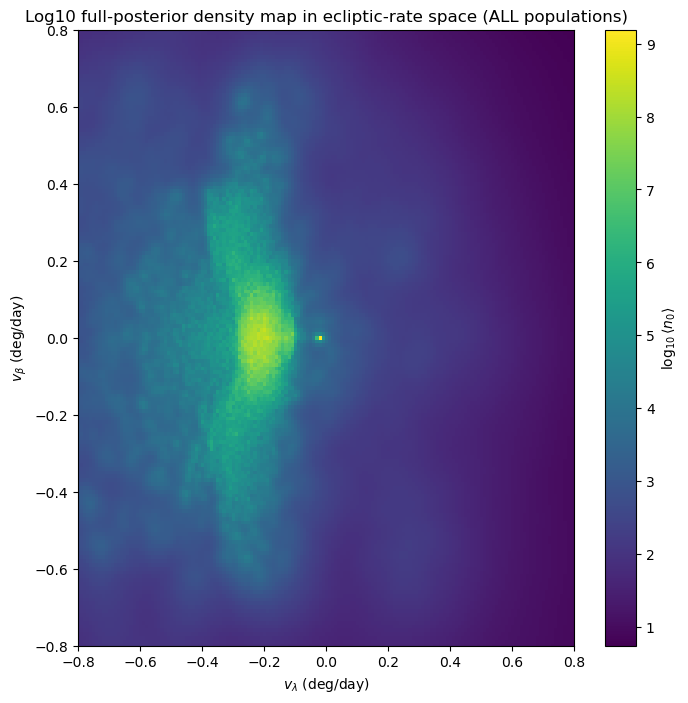

In [37]:
# Plot log10 density map


density_all_map = density_all_flat.reshape(X0.shape)

log_density_all_map = np.log10(density_all_map)

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.pcolormesh(
    X0, Y0, log_density_all_map,
    shading="auto"
)

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title("Log10 full-posterior density map in ecliptic-rate space (ALL populations)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

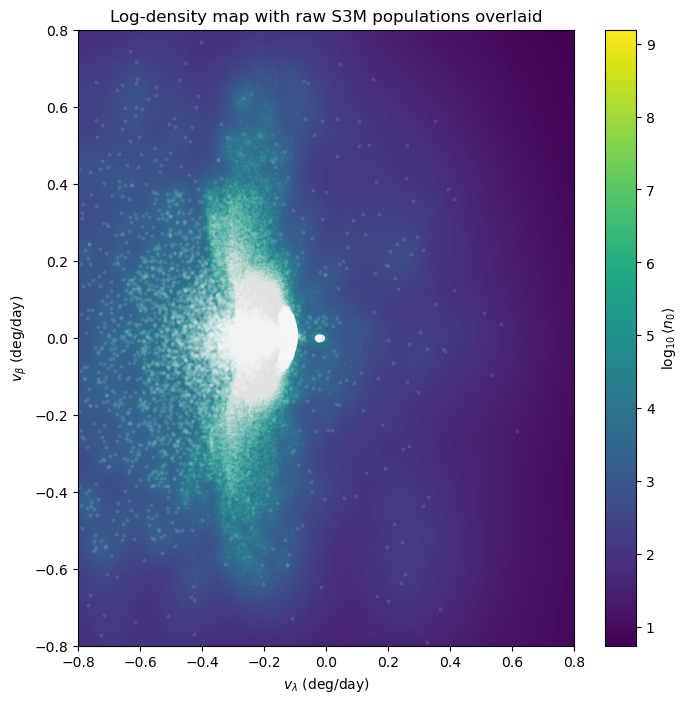

In [38]:
# Overlay raw population points on log-density map

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.pcolormesh(
    X0, Y0, log_density_all_map,
    shading="auto"
)

# Overlay a light scatter of the raw points
ax.scatter(vlam_mba, vbeta_mba, s=1, alpha=0.03, color="white", rasterized=True)
ax.scatter(vlam_neo, vbeta_neo, s=4, alpha=0.08, color="white", rasterized=True)
ax.scatter(vlam_tno, vbeta_tno, s=6, alpha=0.10, color="white", rasterized=True)
ax.scatter(vlam_tjn, vbeta_tjn, s=6, alpha=0.10, color="white", rasterized=True)

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title("Log-density map with raw S3M populations overlaid")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

In [39]:
# First full-map run on just MBA populations

k_map = 10
n_d0_grid_map = 400   # lighter than 800 for first full-map test

density_all_flat = evaluate_density_map_full_posterior_2d(
    tree_mba,
    grid_points,
    k=k_map,
    n_d0_grid=n_d0_grid_map,
    show_progress=True,
)

print("Done.")
print("density_all_flat shape:", density_all_flat.shape)
print("min density:", np.nanmin(density_all_flat))
print("max density:", np.nanmax(density_all_flat))
print("median density:", np.nanmedian(density_all_flat))

Evaluating density map: 100%|██████████| 25921/25921 [08:02<00:00, 53.75it/s]

Done.
density_all_flat shape: (25921,)
min density: 2.024184397171499
max density: 296989163.749541
median density: 27.372301507994123


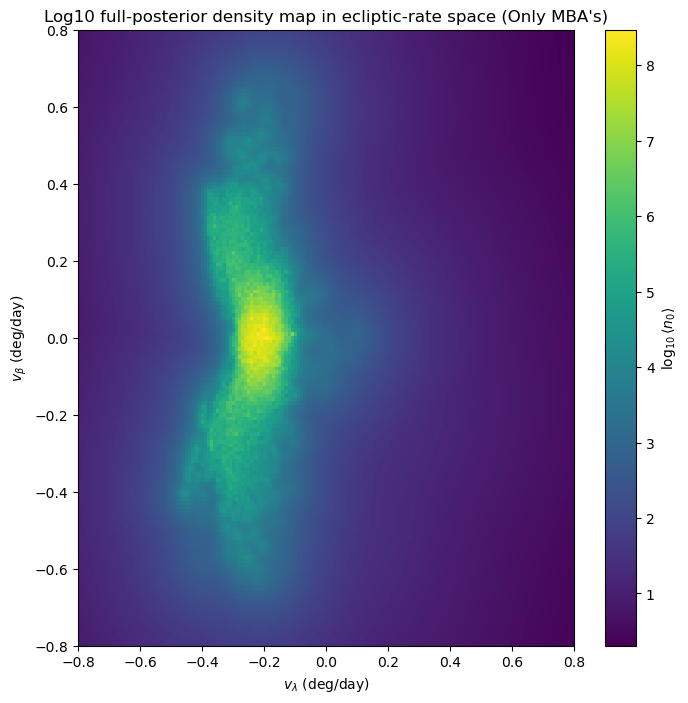

In [40]:
# Plot log10 density map


density_all_map = density_all_flat.reshape(X0.shape)

log_density_all_map = np.log10(density_all_map)

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.pcolormesh(
    X0, Y0, log_density_all_map,
    shading="auto"
)

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title("Log10 full-posterior density map in ecliptic-rate space (Only MBA's)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

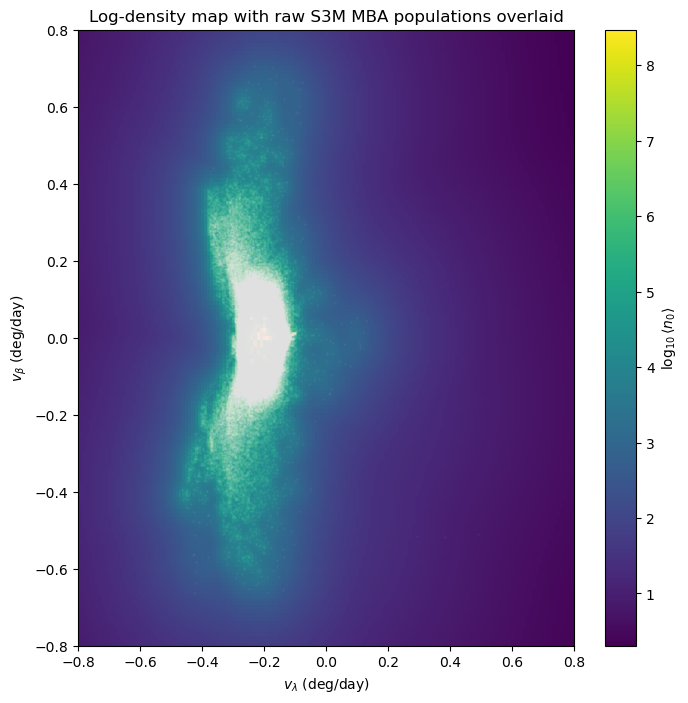

In [45]:
# Overlay MBA population points on log-density map

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.pcolormesh(
    X0, Y0, log_density_all_map,
    shading="auto"
)

# Overlay a light scatter of the raw points
ax.scatter(vlam_mba, vbeta_mba, s=1, alpha=0.03, color="white", rasterized=True)

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title("Log-density map with raw S3M MBA populations overlaid")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

In [46]:
# cell to subtract (or i suppose ratio of mba to all pops to get probability)

### NEO probability map

In [47]:
# First full-map run on just MBA populations

k_map = 10
n_d0_grid_map = 400   # lighter than 800 for first full-map test

density_all_flat = evaluate_density_map_full_posterior_2d(
    tree_neo,
    grid_points,
    k=k_map,
    n_d0_grid=n_d0_grid_map,
    show_progress=True,
)

print("Done.")
print("density_all_flat shape:", density_all_flat.shape)
print("min density:", np.nanmin(density_all_flat))
print("max density:", np.nanmax(density_all_flat))
print("median density:", np.nanmedian(density_all_flat))

Evaluating density map: 100%|██████████| 25921/25921 [08:02<00:00, 53.73it/s]


Done.
density_all_flat shape: (25921,)
min density: 5.552269206645225
max density: 1783448.0028101231
median density: 143.8826875057768


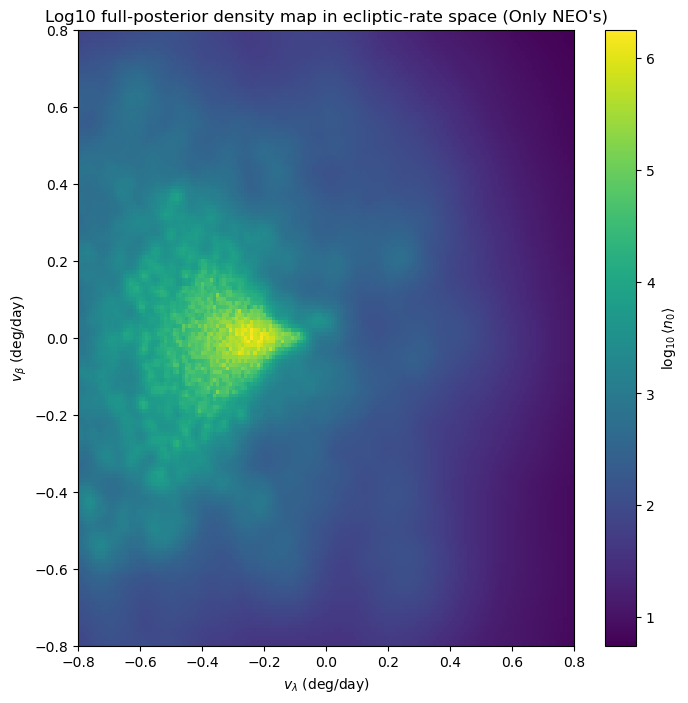

In [48]:
# Plot log10 density map


density_all_map = density_all_flat.reshape(X0.shape)

log_density_all_map = np.log10(density_all_map)

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.pcolormesh(
    X0, Y0, log_density_all_map,
    shading="auto"
)

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title("Log10 full-posterior density map in ecliptic-rate space (Only NEO's)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

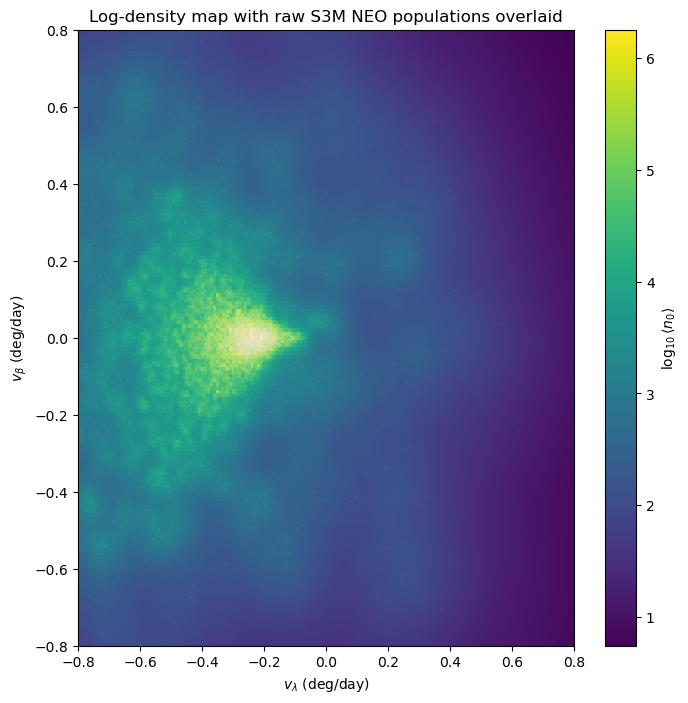

In [49]:
# Overlay NEO population points on log-density map

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.pcolormesh(
    X0, Y0, log_density_all_map,
    shading="auto"
)

# Overlay a light scatter of the raw points
ax.scatter(vlam_neo, vbeta_neo, s=1, alpha=0.03, color="white", rasterized=True)

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title("Log-density map with raw S3M NEO populations overlaid")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

In [50]:
# ------------------------------------------------------------
# Build full-posterior density maps for all 4 populations
# ------------------------------------------------------------
k_map = 10
n_d0_grid_map = 400

pop_info = {
    "MBA": {
        "tree": tree_mba,
        "vlam": vlam_mba,
        "vbeta": vbeta_mba,
        "scatter_size": 1,
        "scatter_alpha": 0.05,
    },
    "NEO": {
        "tree": tree_neo,
        "vlam": vlam_neo,
        "vbeta": vbeta_neo,
        "scatter_size": 4,
        "scatter_alpha": 0.08,
    },
    "TNO": {
        "tree": tree_tno,
        "vlam": vlam_tno,
        "vbeta": vbeta_tno,
        "scatter_size": 6,
        "scatter_alpha": 0.10,
    },
    "Trojans": {
        "tree": tree_tjn,
        "vlam": vlam_tjn,
        "vbeta": vbeta_tjn,
        "scatter_size": 6,
        "scatter_alpha": 0.10,
    },
}

density_maps = {}
log_density_maps = {}

for pop_name, info in pop_info.items():
    print(f"\nEvaluating {pop_name} density map...")

    density_flat = evaluate_density_map_full_posterior_2d(
        info["tree"],
        grid_points,
        k=k_map,
        n_d0_grid=n_d0_grid_map,
        show_progress=True,
    )

    density_map = density_flat.reshape(X0.shape)
    log_density_map = np.log10(density_map)

    density_maps[pop_name] = density_map
    log_density_maps[pop_name] = log_density_map

    print(f"{pop_name} done.")
    print("  min density   :", np.nanmin(density_flat))
    print("  max density   :", np.nanmax(density_flat))
    print("  median density:", np.nanmedian(density_flat))


Evaluating MBA density map...


Evaluating density map: 100%|██████████| 25921/25921 [07:59<00:00, 54.11it/s]


MBA done.
  min density   : 2.024184397171499
  max density   : 296989163.749541
  median density: 27.372301507994123

Evaluating NEO density map...


Evaluating density map:  90%|████████▉ | 23313/25921 [07:07<00:47, 55.18it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

Evaluating density map: 100%|██████████| 25921/25921 [07:58<00:00, 54.21it/s]


TNO done.
  min density   : 1.332224176117387
  max density   : 1549739909.3767836
  median density: 4.289869006270611

Evaluating Trojans density map...


Evaluating density map: 100%|██████████| 25921/25921 [07:57<00:00, 54.25it/s]

Trojans done.
  min density   : 1.2495602810180113
  max density   : 41966992.940762006
  median density: 5.132460262663298


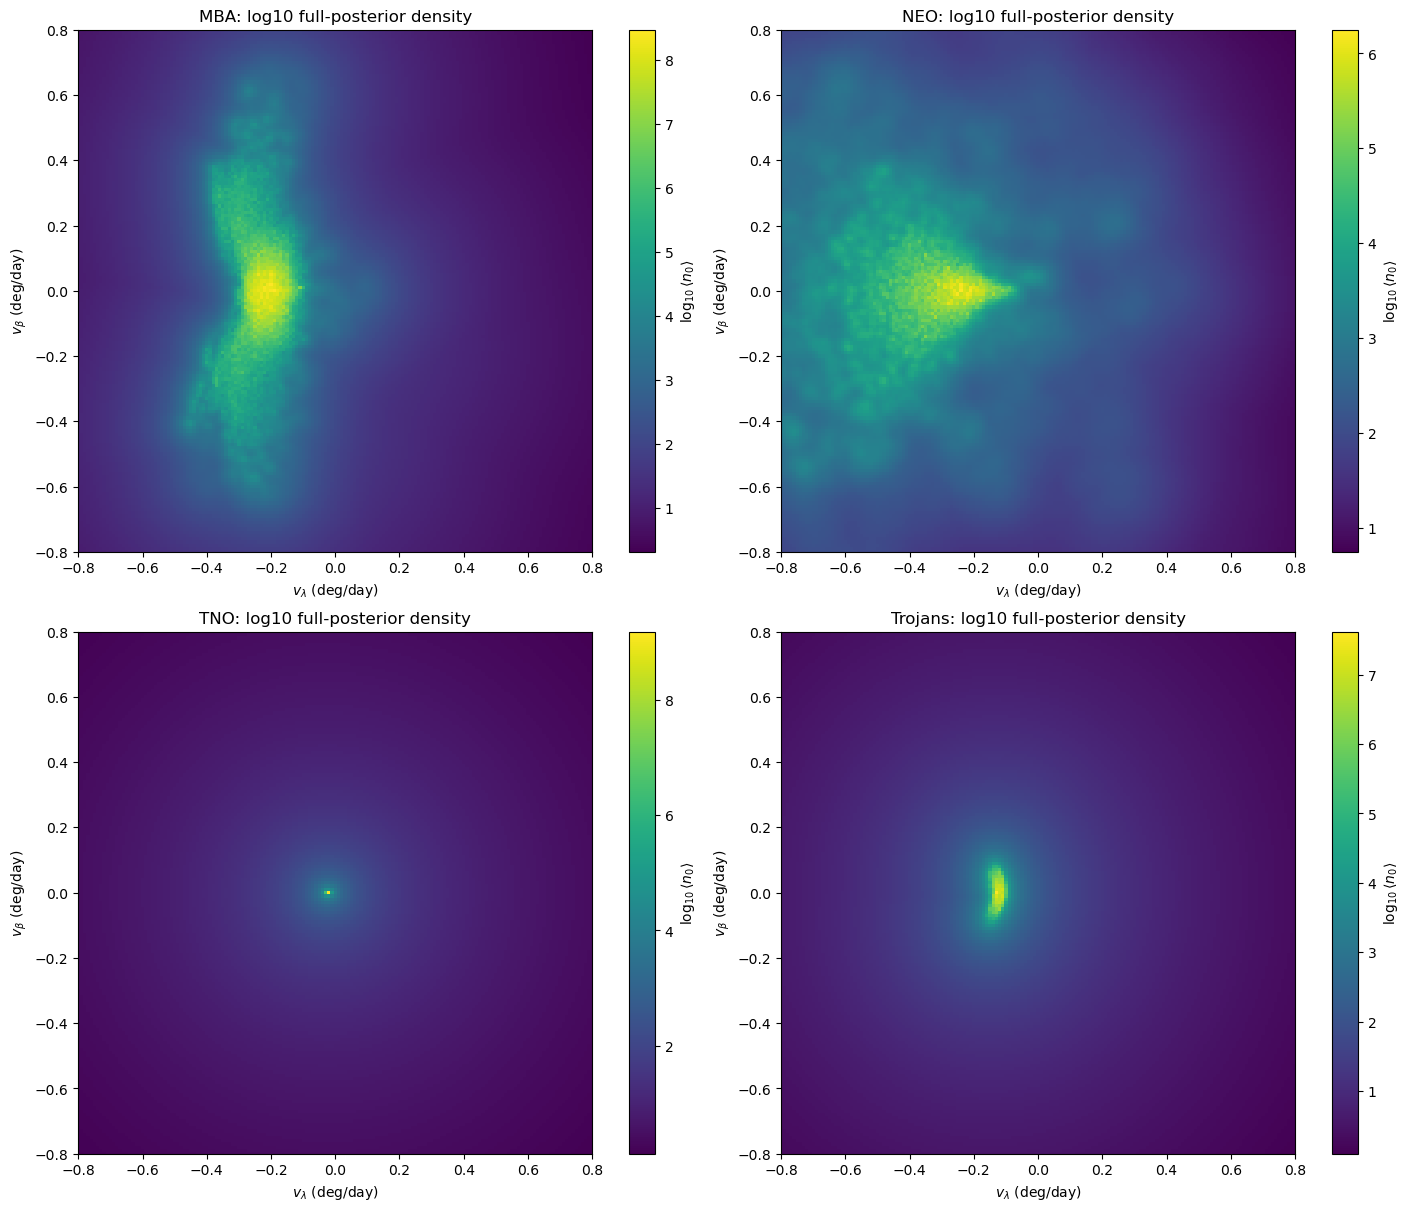

In [51]:
# ------------------------------------------------------------
# Plot all 4 log-density maps (no raw objects)
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

for ax, pop_name in zip(axes, pop_info.keys()):
    im = ax.pcolormesh(
        X0, Y0, log_density_maps[pop_name],
        shading="auto"
    )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: log10 full-posterior density")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$\log_{10}\langle n_0 \rangle$")

plt.show()